# 05 KNN with Iris: 可视化理解最近邻分类

目标：不用先纠结所有数学细节，先通过图像直观看懂 KNN 在做什么。

本 notebook 会做这些事：

1. 读取 Iris 鸢尾花数据集。
2. 只选两个特征，方便画二维图。
3. 画出三类鸢尾花散点图。
4. 选一个测试样本。
5. 画出它和训练样本的关系。
6. 高亮最近的 K 个邻居。
7. 用投票得到预测类别。
8. 观察不同 `k` 的变化。

## 1. 导入依赖

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)

## 2. 读取 Iris 数据集

Iris 数据集有 150 朵花，4 个特征，3 个类别。为了方便画图，我们这次只选两个特征。

In [2]:
iris = load_iris()

X_all = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("X_all shape:", X_all.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

X_all shape: (150, 4)
y shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


## 3. 只选择两个特征

请你填写 `FEATURE_INDEX_1` 和 `FEATURE_INDEX_2`。

建议先试：

- `2`：petal length
- `3`：petal width

因为这两个特征通常比较容易把三类花分开。

In [4]:
FEATURE_INDEX_1 = 2  # TODO: 你来填，例如 2
FEATURE_INDEX_2 = 3  # TODO: 你来填，例如 3

assert FEATURE_INDEX_1 is not None, "请先填写 FEATURE_INDEX_1，例如 2"
assert FEATURE_INDEX_2 is not None, "请先填写 FEATURE_INDEX_2，例如 3"

X = X_all[:, [FEATURE_INDEX_1, FEATURE_INDEX_2]]
selected_feature_names = [feature_names[FEATURE_INDEX_1], feature_names[FEATURE_INDEX_2]]

print("Selected feature names:", selected_feature_names)
print("X shape:", X.shape)
print(X[:5])

Selected feature names: ['petal length (cm)', 'petal width (cm)']
X shape: (150, 2)
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


## 4. 先看散点图

这里的每个点代表一朵花。不同颜色代表不同类别。

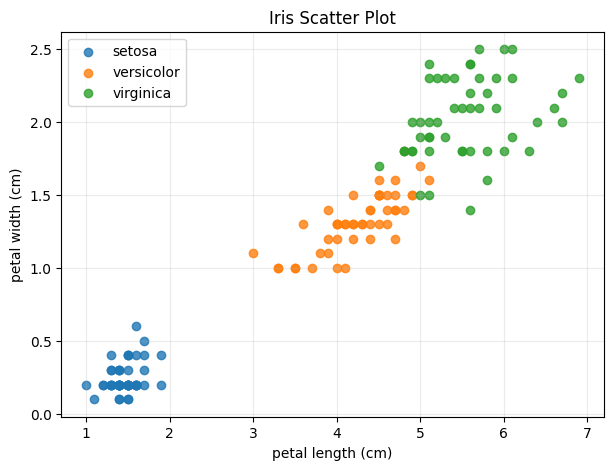

In [5]:
colors = ["tab:blue", "tab:orange", "tab:green"]

for class_id, class_name in enumerate(target_names):
    subset = X[y == class_id]
    plt.scatter(
        subset[:, 0],
        subset[:, 1],
        label=class_name,
        alpha=0.8,
        color=colors[class_id],
    )

plt.xlabel(selected_feature_names[0])
plt.ylabel(selected_feature_names[1])
plt.title("Iris Scatter Plot")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. 划分训练集和测试集

请你填写 `TEST_SIZE`。

建议先试 `0.2`。

In [7]:
TEST_SIZE = 0.25  # TODO: 你来填，例如 0.2

assert TEST_SIZE is not None, "请先填写 TEST_SIZE，例如 0.2"

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train counts:", np.bincount(y_train))
print("y_test counts:", np.bincount(y_test))

X_train: (112, 2)
X_test: (38, 2)
y_train counts: [38 37 37]
y_test counts: [12 13 13]


## 6. 手写欧氏距离函数

In [8]:
def euclidean_distance(a, b):
    difference = a - b
    squared_difference = difference ** 2
    sum_squared_difference = np.sum(squared_difference)
    return np.sqrt(sum_squared_difference)

## 7. 找最近的 K 个邻居

请你填写 `K` 和 `TEST_SAMPLE_INDEX`。

建议先试：

- `K = 5`
- `TEST_SAMPLE_INDEX = 0`

我们先只看一个测试样本。

In [9]:
K = 5                # TODO: 你来填，例如 5
TEST_SAMPLE_INDEX = 0  # TODO: 你来填，例如 0

assert K is not None, "请先填写 K，例如 5"
assert TEST_SAMPLE_INDEX is not None, "请先填写 TEST_SAMPLE_INDEX，例如 0"

def find_neighbors(test_sample, X_train, y_train, k):
    distances = []

    for i in range(len(X_train)):
        train_sample = X_train[i]
        train_label = y_train[i]
        d = euclidean_distance(test_sample, train_sample)
        distances.append((d, train_sample, train_label))

    distances.sort(key=lambda item: item[0])
    neighbors = distances[:k]
    return neighbors


test_sample = X_test[TEST_SAMPLE_INDEX]
true_label = y_test[TEST_SAMPLE_INDEX]
neighbors = find_neighbors(test_sample, X_train, y_train, K)

print("Test sample:", test_sample)
print("True label:", target_names[true_label])
print("Neighbors:")

for distance_value, train_sample, train_label in neighbors:
    print(distance_value, train_sample, target_names[train_label])

Test sample: [1.3 0.2]
True label: setosa
Neighbors:
0.0 [1.3 0.2] setosa
0.0 [1.3 0.2] setosa
0.09999999999999987 [1.4 0.2] setosa
0.09999999999999987 [1.4 0.2] setosa
0.09999999999999987 [1.4 0.2] setosa


## 8. 可视化最近邻

这张图最关键。你会看到：

- 所有训练样本
- 当前测试样本
- 距离它最近的 K 个邻居

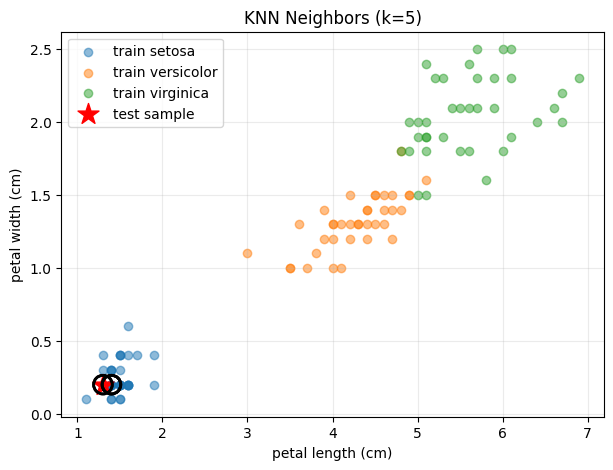

In [10]:
for class_id, class_name in enumerate(target_names):
    subset = X_train[y_train == class_id]
    plt.scatter(
        subset[:, 0],
        subset[:, 1],
        label=f"train {class_name}",
        alpha=0.5,
        color=colors[class_id],
    )

plt.scatter(
    test_sample[0],
    test_sample[1],
    color="red",
    marker="*",
    s=250,
    label="test sample",
)

for _, neighbor_sample, neighbor_label in neighbors:
    plt.scatter(
        neighbor_sample[0],
        neighbor_sample[1],
        facecolors="none",
        edgecolors="black",
        s=180,
        linewidths=2,
    )

plt.xlabel(selected_feature_names[0])
plt.ylabel(selected_feature_names[1])
plt.title(f"KNN Neighbors (k={K})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. 多数投票，得到预测类别

In [11]:
def predict_one(test_sample, X_train, y_train, k):
    neighbors = find_neighbors(test_sample, X_train, y_train, k)
    labels = [label for _, _, label in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction


predicted_label = predict_one(test_sample, X_train, y_train, K)

print("Predicted label:", target_names[predicted_label])
print("True label:", target_names[true_label])

Predicted label: setosa
True label: setosa


## 10. 对整个测试集做预测

In [12]:
def predict_all(X_test, X_train, y_train, k):
    predictions = []

    for test_sample in X_test:
        pred = predict_one(test_sample, X_train, y_train, k)
        predictions.append(pred)

    return np.array(predictions)


y_pred = predict_all(X_test, X_train, y_train, K)
accuracy = accuracy_score(y_test, y_pred)

print("y_test:", y_test)
print("y_pred:", y_pred)
print(f"Accuracy: {accuracy:.4f}")

y_test: [0 1 1 1 0 1 2 2 2 2 2 2 1 1 0 0 0 1 0 1 2 1 2 1 2 1 0 2 0 1 2 2 0 0 0 0 2
 1]
y_pred: [0 1 1 1 0 1 2 2 2 2 1 2 1 1 0 0 0 1 0 1 2 1 2 1 2 1 0 2 0 2 2 2 0 0 0 0 2
 1]
Accuracy: 0.9474


## 11. 比较不同的 K

你会发现 K 太小和 K 太大都可能不好。

k=1, accuracy=0.9737
k=3, accuracy=0.9474
k=5, accuracy=0.9474
k=7, accuracy=0.9474
k=9, accuracy=0.9474
k=11, accuracy=0.9474


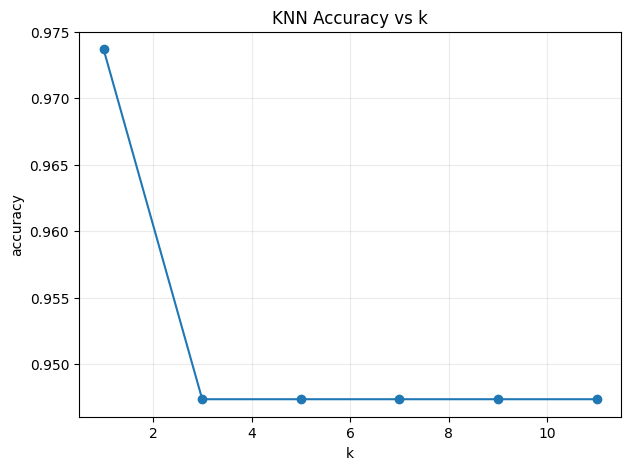

In [13]:
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k_value in k_values:
    pred = predict_all(X_test, X_train, y_train, k_value)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"k={k_value}, accuracy={acc:.4f}")

plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("KNN Accuracy vs k")
plt.grid(alpha=0.25)
plt.show()

## 12. 总结

请你完成下面的问题：

1. 为什么这次只选两个特征，而不是四个？
2. 为什么 KNN 要先算距离？
3. `k` 太小会有什么问题？`k` 太大会有什么问题？
4. 当前哪个 `k` 在测试集上效果最好？这个结果是否可能受测试集划分影响？
5. 这次和前面逻辑回归、决策树相比，KNN 的思路有什么不同？

我的总结：

- 这次实验使用 Iris 鸢尾花数据集，完成了一个非常经典的 KNN 多分类任务。数据集中每个样本有 4 个特征，目标是把花分成 3 个类别。为了方便可视化，我只选了两个特征，在二维平面上观察不同类别的分布，并通过距离计算理解 KNN 的工作方式。
- KNN 的核心思想不是先学习一个显式公式，而是对一个新的测试样本，去训练集中寻找距离它最近的 K 个邻居，然后用这些邻居的类别投票，决定最终预测结果。这个过程让我直观理解了“距离越近，样本越相似”这件事。K 值的选择很重要：K 太小，模型容易对局部噪声敏感；K 太大，模型会被更大范围的样本影响，边界变得过于平滑。
- 这次实验也说明了可视化的重要性。通过散点图、测试样本位置和最近邻高亮，我不只是看到了最后的预测结果，还看到了模型是如何一步一步做出判断的。对于初学阶段，这种方法比只看 accuracy 更容易建立直觉。
- 以后如果要做一个完整的多分类任务，我应该遵循这样的流程：先明确任务和标签，理解数据和类别分布，做基础探索和可视化，划分训练集和测试集，建立一个 baseline，选择合适的评估指标，训练并观察错误，调整关键超参数，比较多个模型，检查是否过拟合，最后再用测试集做最终评估。重点不在于一开始追求复杂模型，而在于先把流程跑通，再逐步提高质量。
- 对我来说，这次 KNN 实验的价值不只是学会了一个算法，而是第一次比较完整地感受到多分类任务的基本流程：数据进入模型之前要先理解，模型结果出来之后要先分析，再决定下一步如何改进。这个流程以后在逻辑回归、决策树、随机森林、SVM 甚至神经网络中都同样适用。